# Linear Regression

## Exercise

本项目使用 PyTorch 进行一个简单的线性回归实验，基于单个特征来预测目标变量。

**数据生成**:
- 我们使用 `sklearn.datasets.make_regression()` 生成 100 个样本，每个样本包含：
  - 一个特征变量 `X`，用于预测目标变量 `y`
  - 目标变量 `y` 受 `X` 影响，并加入一定的噪声

**任务列表**:
1. **数据转换**:
   - **TODO:** 使用 `torch.from_numpy()` 将 `X_numpy` 和 `y_numpy` 转换为 PyTorch 的 `tensor`。

2. **定义线性回归模型**:
   - 实现 `LinearRegressionModel`，包含一个 `nn.Linear(1,1)` 层。

3. **选择损失函数**:
   - **TODO:** 采用均方误差损失函数 `nn.MSELoss()`。

4. **选择优化器**:
   - **TODO:** 采用随机梯度下降 (SGD) 并设置学习率 `0.01`。

5. **训练模型**:
   - **TODO:** 在每轮训练中：
     - 进行前向传播，使用模型对 `X` 进行预测。
     - 计算损失。
5. **画图**:
   - **TODO:** 将tensor结果转换为numpy进行画图

## Inport 

In [1]:
# 导入PyTorch库，用于构建和训练神经网络
import torch
# 导入PyTorch的神经网络模块
import torch.nn as nn
# 导入NumPy库，用于数值计算
import numpy as np
# 从sklearn导入数据集模块，用于生成测试数据
from sklearn import datasets
# 导入Matplotlib库，用于数据可视化
import matplotlib.pyplot as plt

## Prepare data



In [2]:
# 使用sklearn的datasets模块生成回归数据集
X_numpy, y_numpy = datasets.make_regression(n_samples=100, n_features=1, noise=30, random_state=4)

# TODO: 将X_numpy, y_numpy转换为tensor
X = torch.from_numpy(X_numpy.astype(np.float32))
y = torch.from_numpy(y_numpy.astype(np.float32))

# 将y的形状从一维(100,)调整为二维(100,1)，以适应模型训练
y = y.view(y.shape[0], 1)

# 获取X的形状信息：n_samples表示样本数，n_features表示特征数
n_samples, n_features = X.shape

## Model


In [3]:
# Linear model f = wx + b
input_size = n_features
output_size = 1

# TODO: 创建一个线性模型，使用 PyTorch 提供的 nn.Linear
model = nn.Linear(input_size,output_size)

## Loss and optimizer

In [4]:
# TODO: 选择损失函数，使用均方误差损失函数 (MSELoss)
criterion = nn.MSELoss()

# TODO: 选择优化器，使用随机梯度下降 (SGD) 并设置学习率
learning_rate = 0.01
optimizer = torch.optim.SGD(model.parameters(),lr=learning_rate)

 ## Training loop

In [5]:
num_epochs = 100
for epoch in range(num_epochs):
    # Forward pass and loss
    # TODO: 进行前向传播，使用模型对 X 进行预测
    y_predicted = model(X)
    
    # TODO: 计算损失，使用前面定义的损失函数
    loss =criterion(y_predicted,y)
    

    # 计算梯度
    loss.backward()

    # 根据梯度更新模型参数
    optimizer.step()

    # 在新的一步之前清零梯度，防止梯度累积
    optimizer.zero_grad()

    if (epoch+1) % 10 == 0:
        print(f'epoch: {epoch+1}, loss = {loss.item():.4f}')



epoch: 10, loss = 4411.4771
epoch: 20, loss = 3217.0637
epoch: 30, loss = 2402.5554
epoch: 40, loss = 1847.0027
epoch: 50, loss = 1467.9989
epoch: 60, loss = 1209.3875
epoch: 70, loss = 1032.8916
epoch: 80, loss = 912.4148
epoch: 90, loss = 830.1616
epoch: 100, loss = 773.9947


## plot

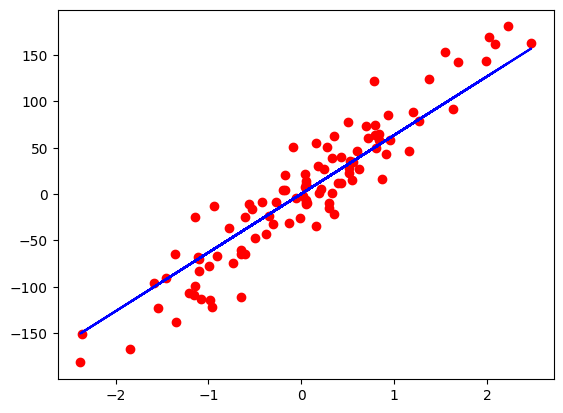

In [7]:
# Plot
# TODO: 将输出先从计算图中分离，然后转为numpy
predicted = model(X).detach().numpy()

plt.plot(X_numpy, y_numpy, 'ro')
plt.plot(X_numpy, predicted, 'b')
plt.show()